### Importing the Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter

import sys
print(sys.version)
print(sys.executable)


from tkinter import messagebox, filedialog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier
from joblib import dump, load

from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Setting up directories
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
C:\Users\bhadr\AppData\Local\Programs\Python\Python313\python.exe



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\bhadr\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\bhadr\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\bhadr\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelapp.py", 

AttributeError: _ARRAY_API not found

### Loading the Dataset

In [2]:
def load_dataset():
    filepath = r"Opticom Signal quality dataset.csv"

    return pd.read_csv(filepath)

In [3]:
df = load_dataset()
df

,Tx,Rx,Various Points,SNR Receiver,SNR Stages,BER Receiver,BER Environmental,Modulation Format,Modulation Depth,Transmission Distance,...,Fiber Attenuation,Splice Losses,Optical Amplifier Gain,PMD Coefficient,PMD Compensation,CD Coefficient,CD Compensation,Temperature,Humidity,Signal Quality
0,10.5,15.2,12.8,23.6,22.1,1.200000e-06,0.000002,AM,0.8,20,...,0.10,0.20,10,0.05,PMD Compensated,0.030,CD Compensated,25.0,60.0,Good
1,11.2,16.5,12.6,24.2,22.8,1.400000e-06,0.000002,FM,0.7,21,...,0.11,0.22,12,0.06,PMD Compensated,0.040,CD Compensated,26.0,61.0,Good
2,9.8,14.8,12.9,23.4,21.9,1.100000e-06,0.000001,PM,0.9,19,...,0.09,0.18,9,0.04,PMD Compensated,0.020,CD Compensated,24.0,59.0,Good
3,12.1,18.2,13.2,24.8,23.5,1.600000e-06,0.000002,AM,0.8,22,...,0.12,0.24,11,0.07,PMD Compensated,0.050,CD Compensated,27.0,62.0,Good
4,10.9,15.8,13.0,24.0,22.5,1.300000e-06,0.000002,FM,0.7,20,...,0.10,0.20,10,0.05,PMD Compensated,0.030,CD Compensated,25.0,60.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,9.9,15.1,12.9,24.0,22.4,1.300000e-06,0.000002,FM,0.7,20,...,0.10,0.20,10,0.05,PMD Compensated,0.030,CD Compensated,25.0,60.0,Good
582,10.8,16.4,13.2,24.3,22.8,1.400000e-06,0.000002,PM,0.9,20,...,0.10,0.20,10,0.05,PMD Compensated,0.030,CD Compensated,25.0,60.0,Good
583,12.9,19.3,13.8,25.5,24.0,1.900000e-06,0.000002,AM,0.8,23,...,0.13,0.26,13,0.08,PMD Compensated,0.060,CD Compensated,28.0,63.0,Good
584,9.3,14.0,12.5,22.8,21.3,8.000000e-07,0.000001,AM,0.8,17,...,0.07,0.14,7,0.02,PMD Compensated,0.009,CD Compensated,22.0,57.0,Poor


In [4]:
df['Signal Quality'].unique()

array(['Good', 'Poor', nan], dtype=object)

### Data Preprocessing

In [5]:
def preprocess_data(df, is_train=True, label_encoders=None):
    # Step 1: Drop unnamed/index columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # Step 2: Drop rows with NaN in target column (Signal Quality or Failure Type)
    target_col = 'Signal Quality'  # Change this to 'Signal Quality' if needed
    if is_train and target_col in df.columns:
        df = df.dropna(subset=[target_col])  # Remove rows with NaN in target

    # Step 3: Label Encoding for categorical columns
    if is_train:
        label_encoders = {}
        for col in df.select_dtypes(include='object').columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    else:
        if label_encoders is None:
            raise ValueError("label_encoders must be provided for test/inference.")
        for col in df.select_dtypes(include='object').columns:
            if col in label_encoders:
                le = label_encoders[col]
                df[col] = le.transform(df[col].astype(str))
            else:
                raise ValueError(f"Missing encoder for column: {col}")

    # Step 4: Fill numeric missing values with column means
    df = df.fillna(df.mean(numeric_only=True))

    # Step 5: Split features and target
    if is_train:
        X = df.drop(columns=['Signal Quality'])
        y = df['Signal Quality']
        return X, y, label_encoders
    else:
        return df


### EDA

In [6]:
def perform_eda(X, y):

    os.makedirs("results", exist_ok=True)
    sns.set(style="whitegrid")

    plt.figure(figsize=(18, 12))

    # 1. Count Plot of Signal Quality (target)
    plt.subplot(2, 3, 1)
    sns.countplot(x=y, palette='viridis')
    plt.title("Distribution of Signal Quality")
    plt.xlabel("Signal Quality")
    plt.ylabel("Count")

    # 2. Boxplot: Tx vs Signal Quality
    plt.subplot(2, 3, 2)
    sns.boxplot(x=y, y=X['Tx'], palette='Set2')
    plt.title("Tx Distribution by Signal Quality")
    plt.xlabel("Signal Quality")
    plt.ylabel("Tx")

    # 3. Violin Plot: Rx vs Signal Quality
    plt.subplot(2, 3, 3)
    sns.violinplot(x=y, y=X['Rx'], palette='coolwarm')
    plt.title("Rx Distribution by Signal Quality")
    plt.xlabel("Signal Quality")
    plt.ylabel("Rx")

    # 4. Boxplot: Modulation Format (categorical) vs Signal Quality
    plt.subplot(2, 3, 4)
    sns.countplot(x=X['Modulation Format'], hue=y, palette='Set1')
    plt.title("Modulation Format Counts by Signal Quality")
    plt.xlabel("Modulation Format")
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # 5. Scatter Plot: SNR Receiver vs BER Receiver colored by Signal Quality
    plt.subplot(2, 3, 5)
    sns.scatterplot(x=X['SNR Receiver'], y=X['BER Receiver'], hue=y, alpha=0.7, palette='Set2')
    plt.title("SNR Receiver vs BER Receiver by Signal Quality")
    plt.xlabel("SNR Receiver")
    plt.ylabel("BER Receiver")

    # 6. Correlation Heatmap for numeric features + Signal Quality encoded as numeric
    plt.subplot(2, 3, 6)
    df_corr = X.copy()
    # Encode y as numeric for correlation
    df_corr['Signal Quality Numeric'] = y.astype('category').cat.codes
    sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation Heatmap including Signal Quality")

    plt.tight_layout()
    plt.savefig("results/eda_plots.png")
    plt.show()


### Applying SMOTE

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Load your data
df = pd.read_csv("Opticom Signal quality dataset.csv")

# Preprocess
X, y, encoders = preprocess_data(df, is_train=True)

# Optional: print class distribution before SMOTE
print("Before SMOTE:\n", y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Optional: print class distribution after SMOTE
print("After SMOTE:\n", pd.Series(y_resampled).value_counts())


Before SMOTE:
 Signal Quality
0    538
1     47
Name: count, dtype: int64
After SMOTE:
 Signal Quality
0    538
1    538
Name: count, dtype: int64


### Train Test Split

In [8]:
def train_test_splitdata(X, y, test_size=0.3, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

### Metrics for Classification

In [9]:
precision = []
recall = []
fscore = []
accuracy = []

labels = [0,1]

# Dataframes to store results
metrics_df = pd.DataFrame(columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
class_report_df = pd.DataFrame()
class_performance_dfs = {}

if not os.path.exists('results'):
    os.makedirs('results')


def Calculate_Metrics(algorithm, predict, y_test, y_score):
    global metrics_df, class_report_df, class_performance_dfs

    categories = labels  # Your class label strings

    # Calculate overall metrics
    a = accuracy_score(y_test, predict) * 100
    p = precision_score(y_test, predict, average='macro') * 100
    r = recall_score(y_test, predict, average='macro') * 100
    f = f1_score(y_test, predict, average='macro') * 100

    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)

    metrics_entry = pd.DataFrame({
        'Algorithm': [algorithm],
        'Accuracy': [a],
        'Precision': [p],
        'Recall': [r],
        'F1-Score': [f]
    })
    metrics_df = pd.concat([metrics_df, metrics_entry], ignore_index=True)

    print(f"{algorithm} Accuracy  : {a:.2f}")
    print(f"{algorithm} Precision : {p:.2f}")
    print(f"{algorithm} Recall    : {r:.2f}")
    print(f"{algorithm} FScore    : {f:.2f}")

    conf_matrix = confusion_matrix(y_test, predict)

    CR = classification_report(y_test, predict, target_names=[str(c) for c in categories], output_dict=True)
    print(f"{algorithm} Classification Report")
    print(f"{algorithm}\n{classification_report(y_test, predict, target_names=[str(c) for c in categories])}\n")

    cr_df = pd.DataFrame(CR).transpose()
    cr_df['Algorithm'] = algorithm
    class_report_df = pd.concat([class_report_df, cr_df], ignore_index=False)

    for category in categories:
        if str(category) in CR:
            class_entry = pd.DataFrame({
                'Algorithm': [algorithm],
                'Precision': [CR[str(category)]['precision'] * 100],
                'Recall': [CR[str(category)]['recall'] * 100],
                'F1-Score': [CR[str(category)]['f1-score'] * 100],
                'Support': [CR[str(category)]['support']]
            })

            if str(category) not in class_performance_dfs:
                class_performance_dfs[str(category)] = pd.DataFrame(columns=['Algorithm', 'Precision', 'Recall', 'F1-Score', 'Support'])

            class_performance_dfs[str(category)] = pd.concat([class_performance_dfs[str(category)], class_entry], ignore_index=True)

    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(conf_matrix, xticklabels=categories, yticklabels=categories, annot=True, cmap="viridis", fmt="g")
    ax.set_ylim([0, len(categories)])
    plt.title(f"{algorithm} Confusion Matrix")
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.savefig(f"results/{algorithm.replace(' ', '_')}_confusion_matrix.png")
    plt.show()

    # --- Modified ROC Plotting ---
    if y_score is not None and len(np.unique(y_test)) > 1:
        try:
            # Binarize y_test with string classes directly
            y_test_bin = label_binarize(y_test, classes=categories)
            print(f"y_test_bin shape: {y_test_bin.shape}")
            print(f"y_score shape: {y_score.shape}")

            fpr = dict()
            tpr = dict()
            roc_auc = dict()

            y_score = np.array(y_score)

            # Handle binary classification case with 1D y_score
            if y_score.ndim == 1 or (y_score.ndim == 2 and y_score.shape[1] == 1):
                print("Adjusting y_score shape for binary classification ROC")
                y_score = np.column_stack([1 - y_score[:, 0], y_score[:, 0]])

            for i in range(y_test_bin.shape[1]):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])

            plt.figure(figsize=(10, 8))
            for i in range(len(roc_auc)):
                plt.plot(fpr[i], tpr[i], label=f'Class {categories[i]} (AUC = {roc_auc[i]:.2f})')

            plt.plot([0, 1], [0, 1], 'k--', label='Random')
            plt.title(f"{algorithm} ROC Curves (One-vs-Rest)")
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend(loc='lower right')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"results/{algorithm.replace(' ', '_')}_roc_curve.png")
            plt.show()

        except Exception as e:
            print(f"ROC plot failed: {e}")


In [10]:
X,y,label_names  = preprocess_data(df,is_train=True)

C:\Users\bhadr\AppData\Local\Temp\ipykernel_38124\3604991480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')
C:\Users\bhadr\AppData\Local\Temp\ipykernel_38124\3604991480.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['Tx'], palette='Set2')
C:\Users\bhadr\AppData\Local\Temp\ipykernel_38124\3604991480.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y, y=X['Rx'], palette='coolwarm')


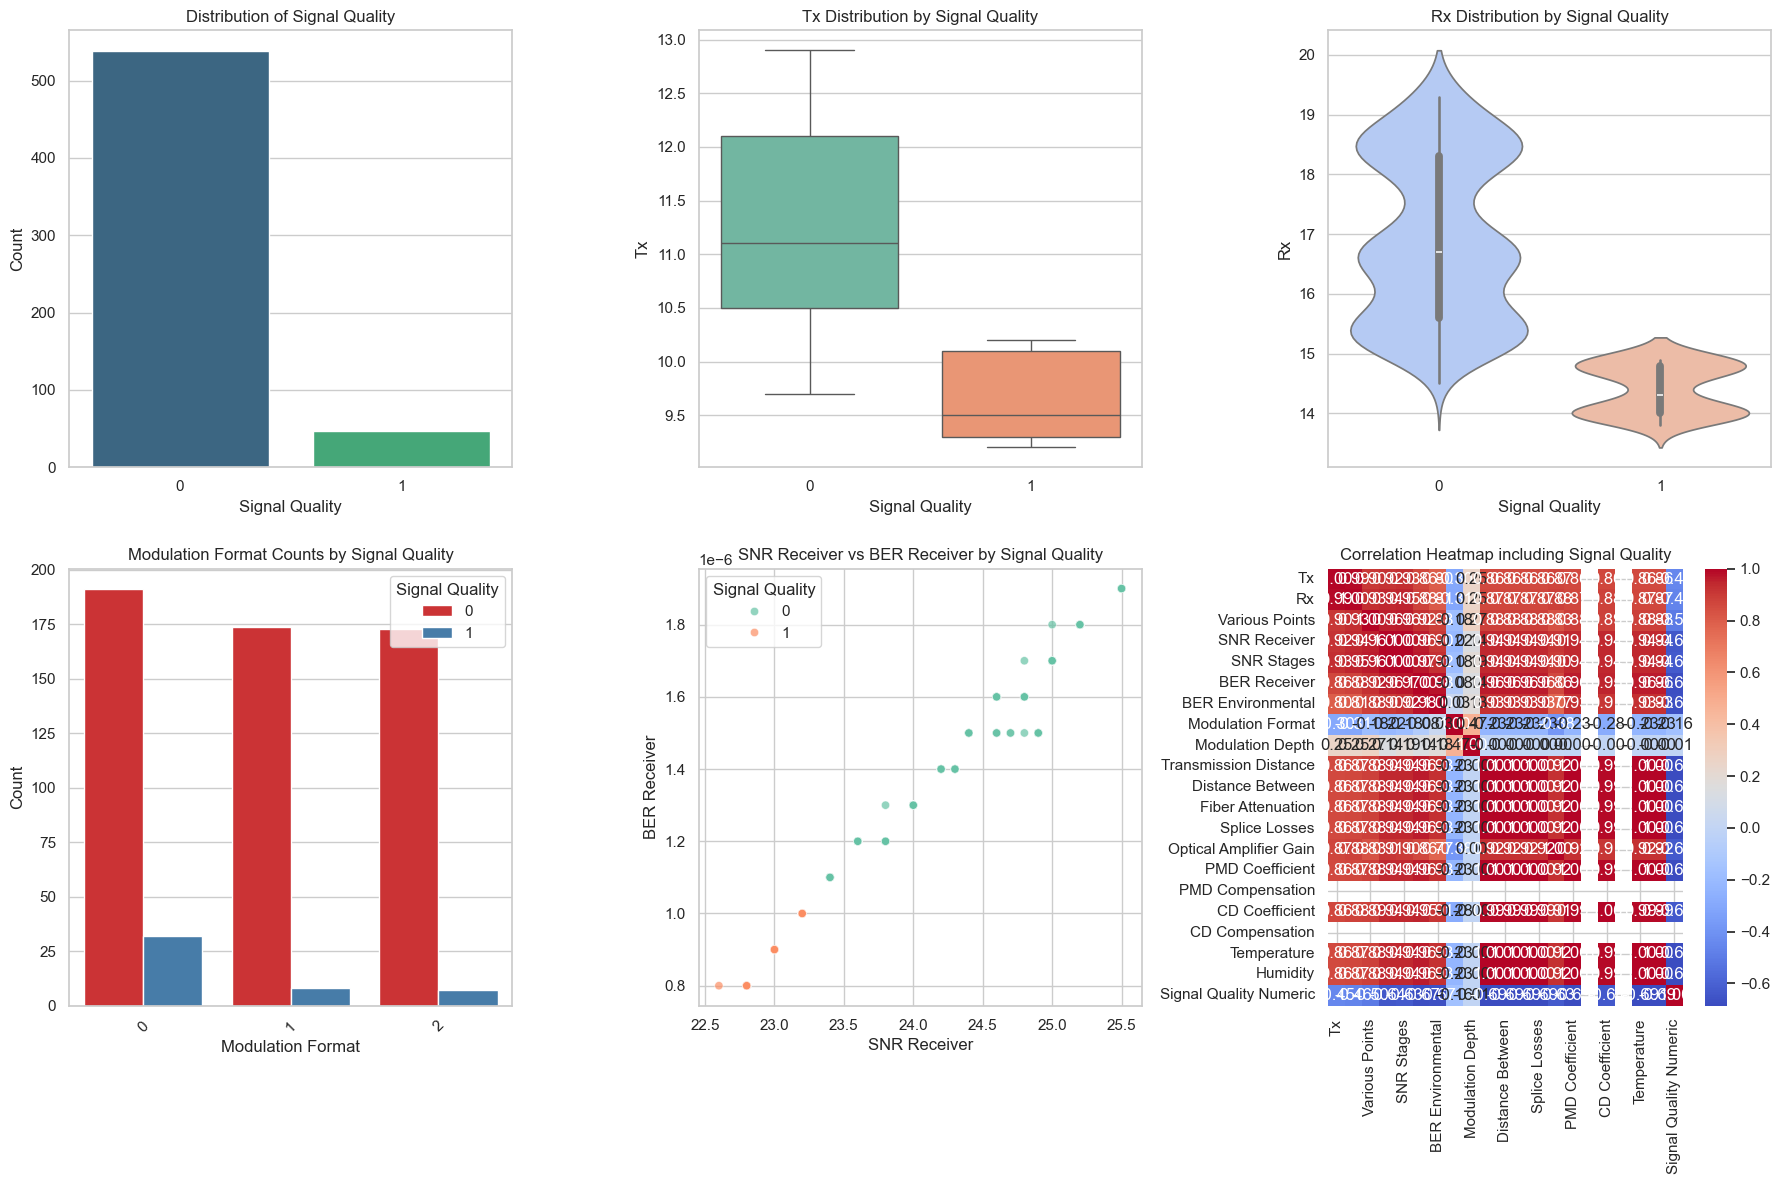

In [11]:
eda = perform_eda(X,y)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

<Axes: xlabel='Signal Quality', ylabel='count'>

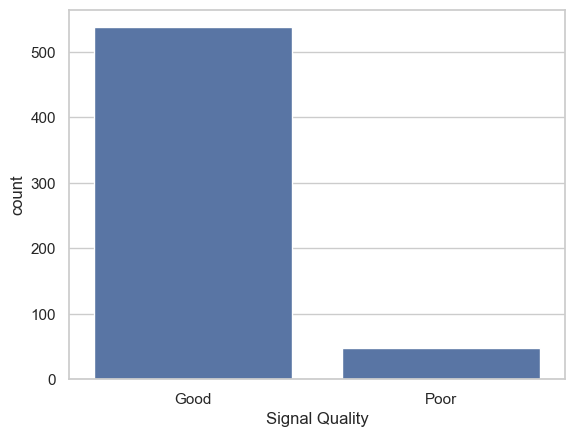

In [13]:
sns.countplot(x = df['Signal Quality'])

<Axes: xlabel='Signal Quality', ylabel='count'>

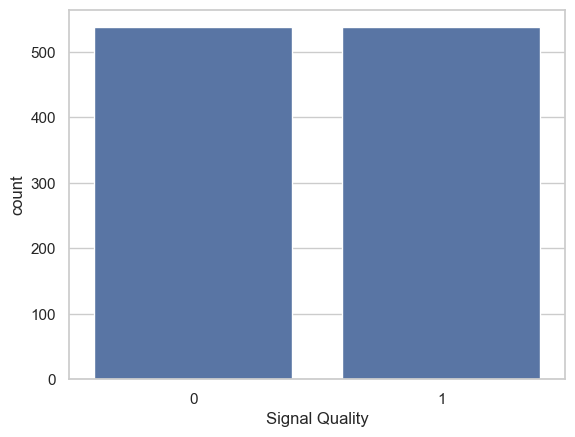

In [14]:
sns.countplot(x=y_resampled)

### Model Building

In [15]:
from sklearn.naive_bayes import ComplementNB
from joblib import dump, load
import os

def train_complement_nb_classifier(X_train, y_train, X_test, y_test, alpha=1.0):
    model_path = os.path.join(MODEL_DIR, 'complement_nb_classifier.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
    else:
        model = ComplementNB(alpha=alpha)
        model.fit(X_train, y_train)
        dump(model, model_path)

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    Calculate_Metrics("Complement Naive Bayes Classifier", y_pred, y_test, y_score)


In [16]:
from sklearn.svm import SVC


def train_svm_classifier(X_train, y_train, X_test, y_test, kernel='rbf', C=1.0, probability=True):
    model_path = os.path.join(MODEL_DIR, 'svm_classifier.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
    else:
        model = SVC(kernel=kernel, C=C, probability=probability, random_state=42)
        model.fit(X_train, y_train)
        dump(model, model_path)

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test) if probability else None
    Calculate_Metrics("SVM Classifier", y_pred, y_test, y_score)


In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import dump, load
import os

def train_lda_classifier(X_train, y_train, X_test, y_test):
    model_path = os.path.join(MODEL_DIR, 'lda_classifier.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
    else:
        model = LinearDiscriminantAnalysis()
        model.fit(X_train, y_train)
        dump(model, model_path)

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)  # LDA supports probability estimates

    Calculate_Metrics("LDA Classifier", y_pred, y_test, y_score)


C:\Users\bhadr\AppData\Local\Temp\ipykernel_38124\3503795406.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, metrics_entry], ignore_index=True)
C:\Users\bhadr\AppData\Local\Temp\ipykernel_38124\3503795406.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  class_performance_dfs[str(category)] = pd.concat([class_performance_dfs[str(category)], class_entry], ignore_index=True)
C:\Users\bhadr\AppData\Local\Temp\ipykernel_38124\3503795406.py:70: FutureWarnin

Complement Naive Bayes Classifier Accuracy  : 93.98
Complement Naive Bayes Classifier Precision : 94.63
Complement Naive Bayes Classifier Recall    : 93.98
Complement Naive Bayes Classifier FScore    : 93.96
Complement Naive Bayes Classifier Classification Report
Complement Naive Bayes Classifier
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       108
           1       1.00      0.88      0.94       108

    accuracy                           0.94       216
   macro avg       0.95      0.94      0.94       216
weighted avg       0.95      0.94      0.94       216




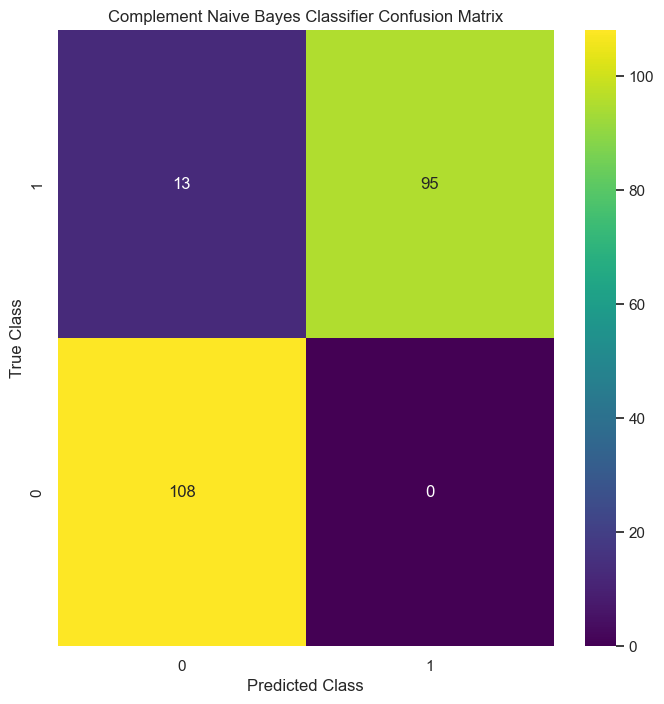

y_test_bin shape: (216, 1)
y_score shape: (216, 2)


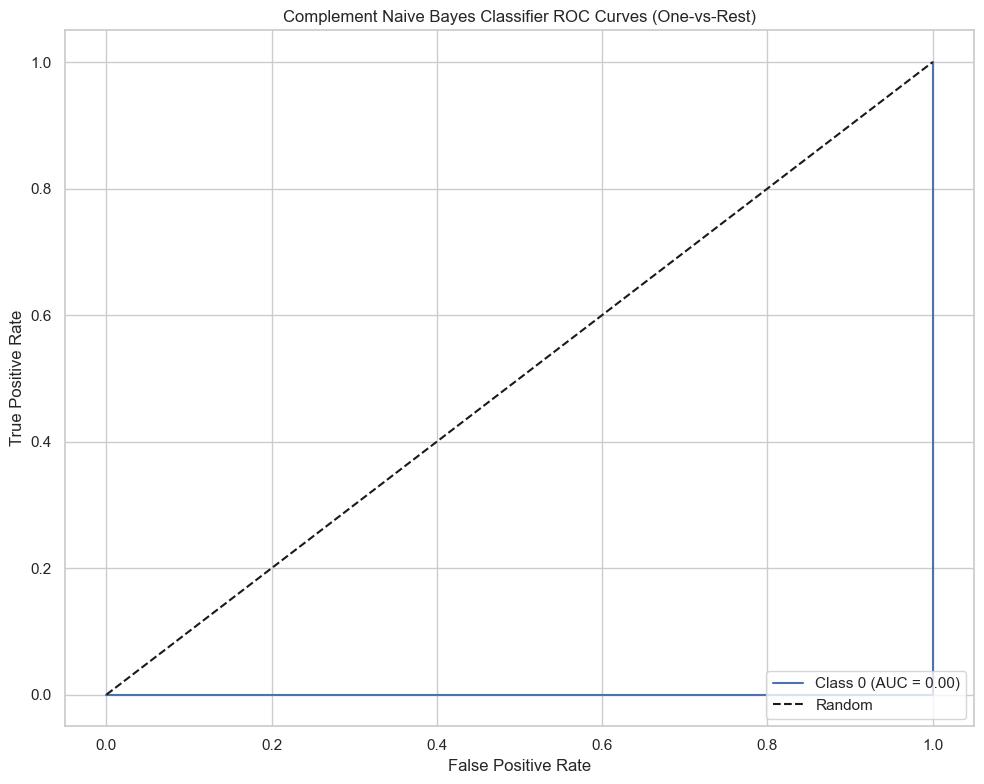

In [18]:
train_complement_nb_classifier(X_train, y_train, X_test, y_test)

SVM Classifier Accuracy  : 98.61
SVM Classifier Precision : 98.65
SVM Classifier Recall    : 98.61
SVM Classifier FScore    : 98.61
SVM Classifier Classification Report
SVM Classifier
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       108
           1       0.97      1.00      0.99       108

    accuracy                           0.99       216
   macro avg       0.99      0.99      0.99       216
weighted avg       0.99      0.99      0.99       216




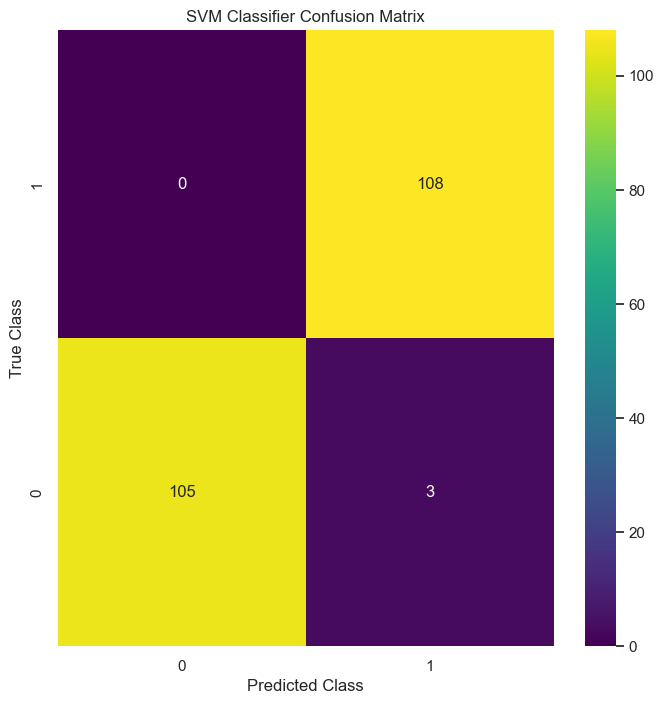

y_test_bin shape: (216, 1)
y_score shape: (216, 2)


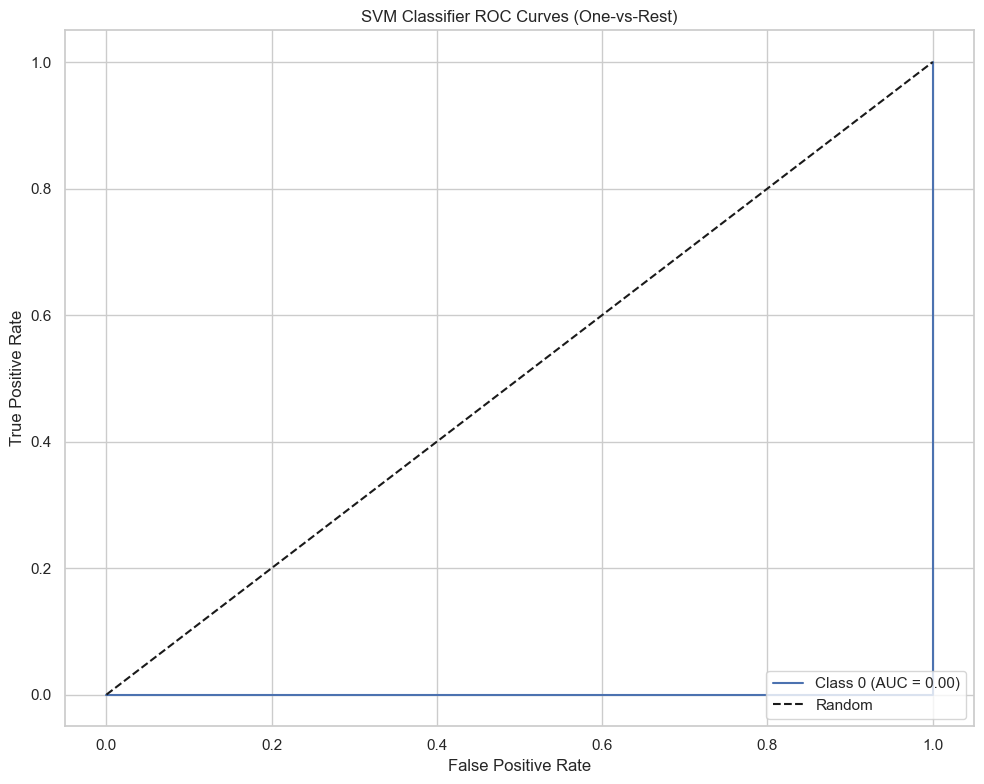

In [19]:
train_svm_classifier(X_train, y_train, X_test, y_test)

LDA Classifier Accuracy  : 99.54
LDA Classifier Precision : 99.54
LDA Classifier Recall    : 99.54
LDA Classifier FScore    : 99.54
LDA Classifier Classification Report
LDA Classifier
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       108
           1       0.99      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216




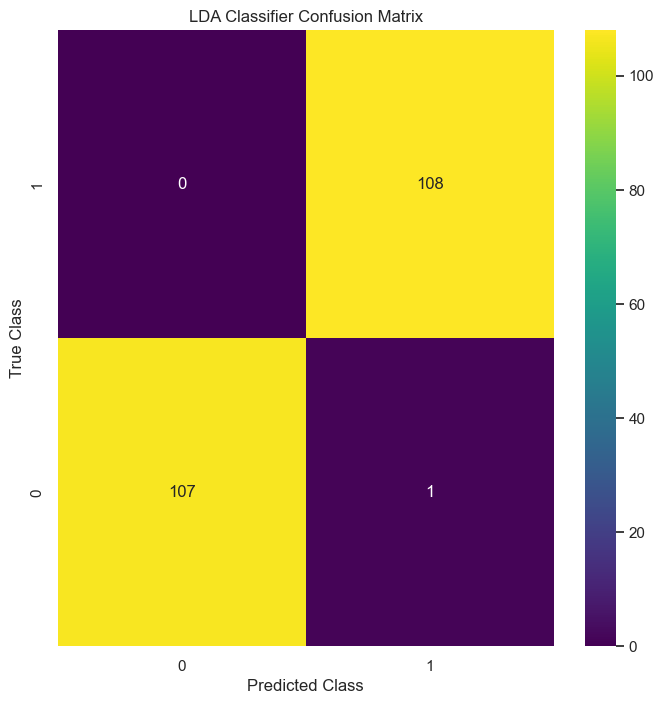

y_test_bin shape: (216, 1)
y_score shape: (216, 2)


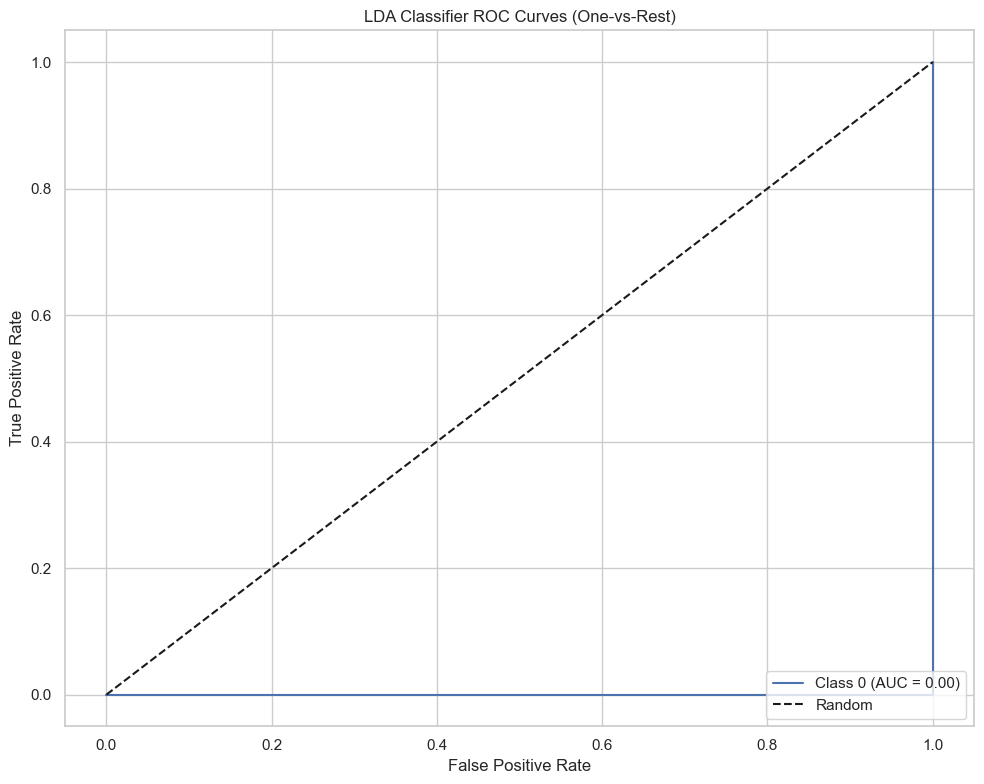

In [20]:
train_lda_classifier(X_train, y_train, X_test, y_test)

### Proposed Hybrid

In [21]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from joblib import dump, load
import os

def train_rf_logreg_voting(X_train, y_train, X_test, y_test):
    model_path = os.path.join(MODEL_DIR, 'rf_logreg_voting.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
    else:
        clf1 = RandomForestClassifier(n_estimators=100, random_state=42)
        clf2 = LogisticRegression(max_iter=1000, random_state=42)

        model = VotingClassifier(estimators=[('rf', clf1), ('logreg', clf2)], voting='soft')
        model.fit(X_train, y_train)
        dump(model, model_path)

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    Calculate_Metrics("Random Forest + Logistic Regression Voting", y_pred, y_test, y_score)


Random Forest + Logistic Regression Voting Accuracy  : 100.00
Random Forest + Logistic Regression Voting Precision : 100.00
Random Forest + Logistic Regression Voting Recall    : 100.00
Random Forest + Logistic Regression Voting FScore    : 100.00
Random Forest + Logistic Regression Voting Classification Report
Random Forest + Logistic Regression Voting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216




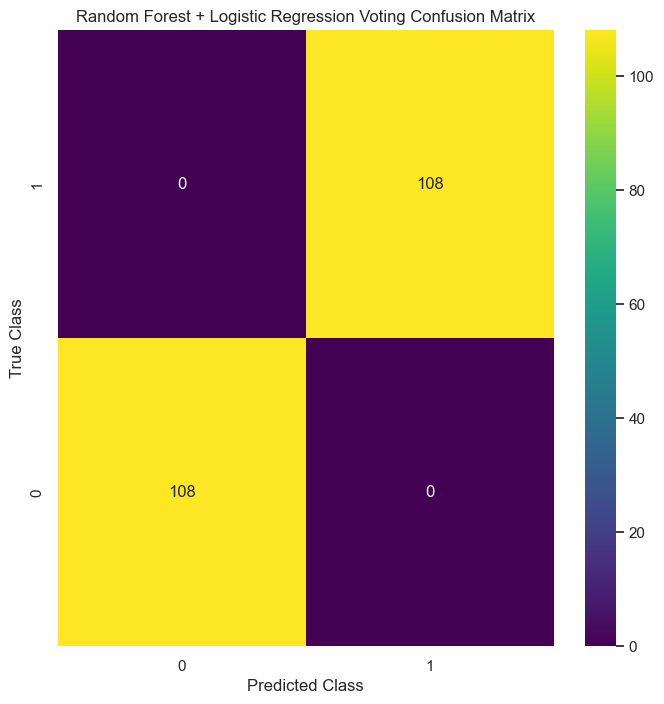

y_test_bin shape: (216, 1)
y_score shape: (216, 2)


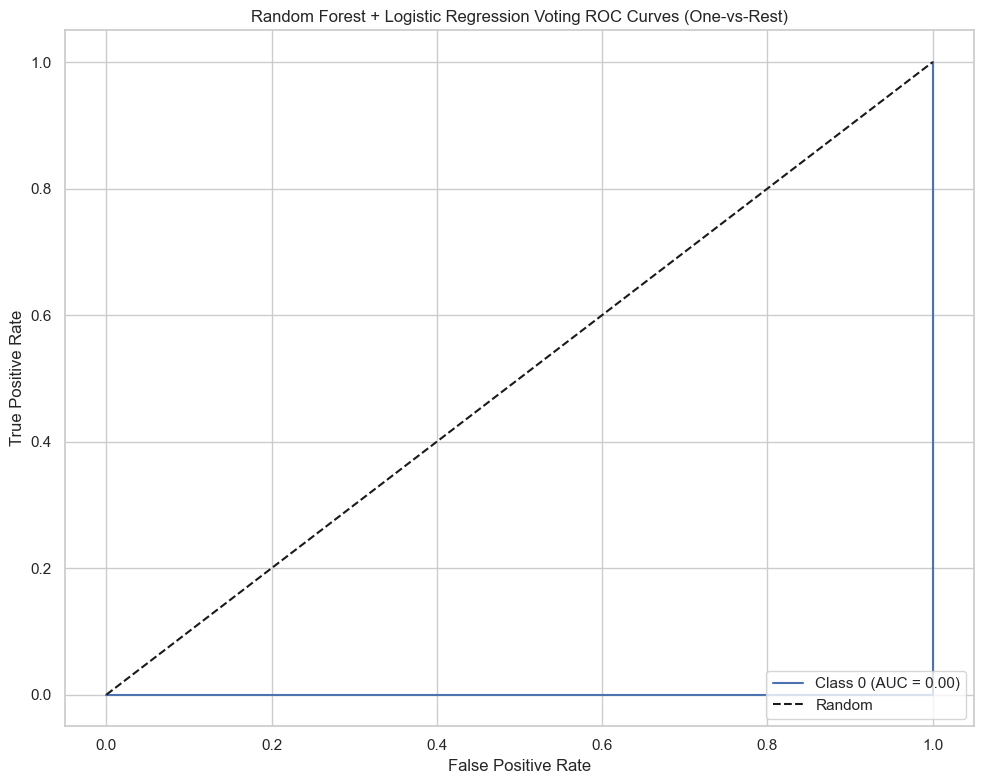

In [22]:
train_rf_logreg_voting(X_train, y_train, X_test, y_test)

In [23]:
metrics_df

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Complement Naive Bayes Classifier,93.981481,94.628099,93.981481,93.959602
1,SVM Classifier,98.611111,98.648649,98.611111,98.610843
2,LDA Classifier,99.537037,99.541284,99.537037,99.537027
3,Random Forest + Logistic Regression Voting,100.000000,100.000000,100.000000,100.000000


In [24]:
def classification_graphs():
    global metrics_df, class_performance_dfs, labels

    # Overall metrics bar plot
    plt.figure(figsize=(12, 8))
    metrics_melted = metrics_df.melt(id_vars='Algorithm', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    sns.barplot(data=metrics_melted, x='Algorithm', y='value', hue='variable')
    plt.title('Overall Classifier Performance Comparison')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 110)
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.savefig('results/overall_performance_comparison.png')
    plt.show()



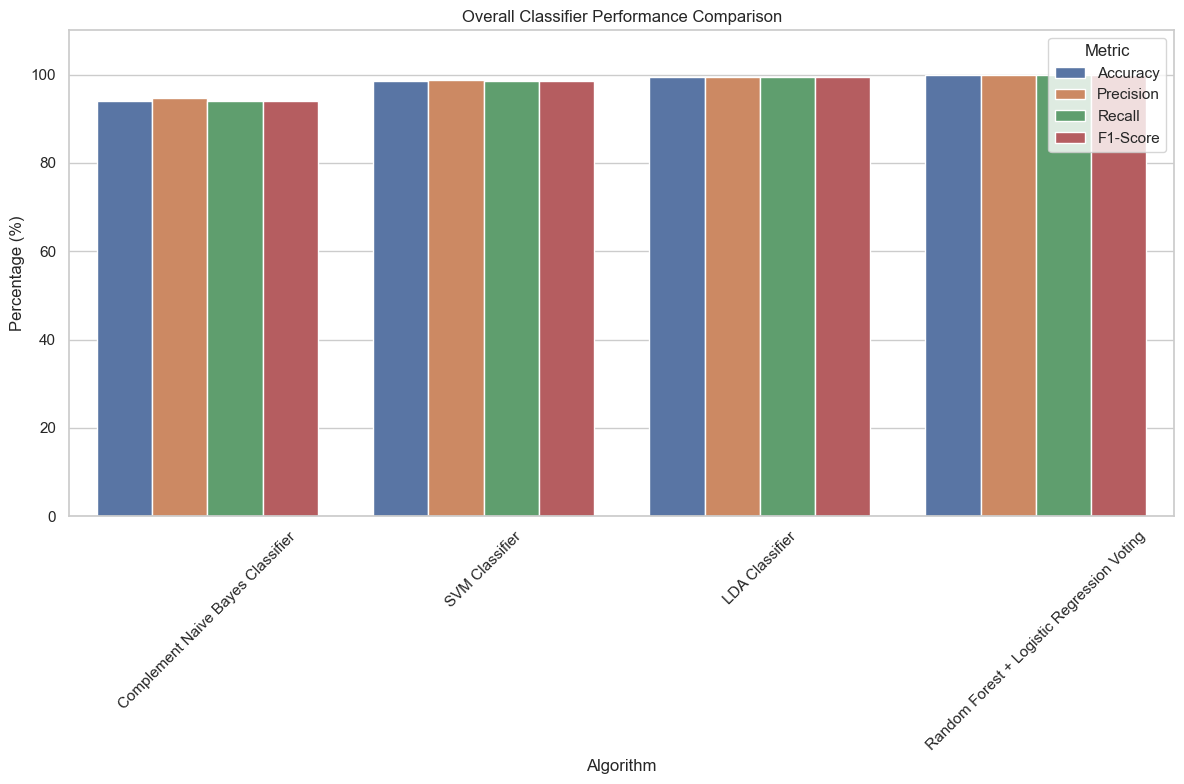

In [25]:
classification_graphs()

### Test Data

In [26]:
test_data = pd.read_csv('TestData.csv')
test_data

,Tx,Rx,Various Points,SNR Receiver,SNR Stages,BER Receiver,BER Environmental,Modulation Format,Modulation Depth,Transmission Distance,Distance Between,Fiber Attenuation,Splice Losses,Optical Amplifier Gain,PMD Coefficient,PMD Compensation,CD Coefficient,CD Compensation,Temperature,Humidity
0,10.5,15.2,12.8,23.6,22.1,1.200000e-06,0.000002,AM,0.8,20,5,0.10,0.20,10,0.05,PMD Compensated,0.03,CD Compensated,25,60
1,11.2,16.5,12.6,24.2,22.8,1.400000e-06,0.000002,FM,0.7,21,6,0.11,0.22,12,0.06,PMD Compensated,0.04,CD Compensated,26,61
2,9.8,14.8,12.9,23.4,21.9,1.100000e-06,0.000001,PM,0.9,19,4,0.09,0.18,9,0.04,PMD Compensated,0.02,CD Compensated,24,59
3,12.1,18.2,13.2,24.8,23.5,1.600000e-06,0.000002,AM,0.8,22,7,0.12,0.24,11,0.07,PMD Compensated,0.05,CD Compensated,27,62
4,10.9,15.8,13.0,24.0,22.5,1.300000e-06,0.000002,FM,0.7,20,5,0.10,0.20,10,0.05,PMD Compensated,0.03,CD Compensated,25,60
5,11.5,16.9,13.3,24.4,22.9,1.500000e-06,0.000002,PM,0.9,21,6,0.11,0.22,12,0.06,PMD Compensated,0.04,CD Compensated,26,61
6,9.7,14.5,12.7,23.2,21.7,1.000000e-06,0.000001,AM,0.8,19,4,0.09,0.18,9,0.04,PMD Compensated,0.02,CD Compensated,24,59
7,12.3,18.5,13.5,25.0,23.7,1.700000e-06,0.000002,FM,0.7,22,7,0.12,0.24,11,0.07,PMD Compensated,0.05,CD Compensated,27,62
8,11.0,16.2,13.1,24.2,22.6,1.400000e-06,0.000002,PM,0.9,20,5,0.10,0.20,10,0.05,PMD Compensated,0.03,CD Compensated,25,60
9,9.5,14.3,12.6,23.0,21.5,9.000000e-07,0.000001,AM,0.8,18,3,0.08,0.16,8,0.03,PMD Compensated,0.01,CD Compensated,23,58


In [27]:
df1=preprocess_data(test_data, is_train=False,label_encoders=label_names)

In [28]:
df1

,Tx,Rx,Various Points,SNR Receiver,SNR Stages,BER Receiver,BER Environmental,Modulation Format,Modulation Depth,Transmission Distance,Distance Between,Fiber Attenuation,Splice Losses,Optical Amplifier Gain,PMD Coefficient,PMD Compensation,CD Coefficient,CD Compensation,Temperature,Humidity
0,10.5,15.2,12.8,23.6,22.1,1.200000e-06,0.000002,0,0.8,20,5,0.10,0.20,10,0.05,0,0.03,0,25,60
1,11.2,16.5,12.6,24.2,22.8,1.400000e-06,0.000002,1,0.7,21,6,0.11,0.22,12,0.06,0,0.04,0,26,61
2,9.8,14.8,12.9,23.4,21.9,1.100000e-06,0.000001,2,0.9,19,4,0.09,0.18,9,0.04,0,0.02,0,24,59
3,12.1,18.2,13.2,24.8,23.5,1.600000e-06,0.000002,0,0.8,22,7,0.12,0.24,11,0.07,0,0.05,0,27,62
4,10.9,15.8,13.0,24.0,22.5,1.300000e-06,0.000002,1,0.7,20,5,0.10,0.20,10,0.05,0,0.03,0,25,60
5,11.5,16.9,13.3,24.4,22.9,1.500000e-06,0.000002,2,0.9,21,6,0.11,0.22,12,0.06,0,0.04,0,26,61
6,9.7,14.5,12.7,23.2,21.7,1.000000e-06,0.000001,0,0.8,19,4,0.09,0.18,9,0.04,0,0.02,0,24,59
7,12.3,18.5,13.5,25.0,23.7,1.700000e-06,0.000002,1,0.7,22,7,0.12,0.24,11,0.07,0,0.05,0,27,62
8,11.0,16.2,13.1,24.2,22.6,1.400000e-06,0.000002,2,0.9,20,5,0.10,0.20,10,0.05,0,0.03,0,25,60
9,9.5,14.3,12.6,23.0,21.5,9.000000e-07,0.000001,0,0.8,18,3,0.08,0.16,8,0.03,0,0.01,0,23,58


In [29]:
def predict_and_append(df_original, df_processed, label_encoders, model_filename='rf_logreg_voting.joblib'):
    model_path = os.path.join(MODEL_DIR, model_filename)

    if not os.path.exists(model_path):
        print("Model file not found.")
        return None

    model = load(model_path)

    # Predict using preprocessed test data
    y_pred = model.predict(df_processed)

    # Decode numeric labels back to original class names
    if 'Signal Quality' in label_encoders:
        y_pred_decoded = label_encoders['Signal Quality'].inverse_transform(y_pred)
    else:
        y_pred_decoded = y_pred

    # Append prediction to original DataFrame
    df_output = df_original.copy()
    df_output['Predicted Label'] = y_pred_decoded

    # Save result
    output_path = os.path.join(RESULTS_DIR, "Predictions_Appended.csv")
    df_output.to_csv(output_path, index=False)
    print(f"Predictions saved to: {output_path}")

    return df_output


In [30]:
final_predicted_df = predict_and_append(test_data, df1, label_names)
final_predicted_df

Predictions saved to: results\Predictions_Appended.csv


,Tx,Rx,Various Points,SNR Receiver,SNR Stages,BER Receiver,BER Environmental,Modulation Format,Modulation Depth,Transmission Distance,...,Fiber Attenuation,Splice Losses,Optical Amplifier Gain,PMD Coefficient,PMD Compensation,CD Coefficient,CD Compensation,Temperature,Humidity,Predicted Label
0,10.5,15.2,12.8,23.6,22.1,1.200000e-06,0.000002,AM,0.8,20,...,0.10,0.20,10,0.05,PMD Compensated,0.03,CD Compensated,25,60,Good
1,11.2,16.5,12.6,24.2,22.8,1.400000e-06,0.000002,FM,0.7,21,...,0.11,0.22,12,0.06,PMD Compensated,0.04,CD Compensated,26,61,Good
2,9.8,14.8,12.9,23.4,21.9,1.100000e-06,0.000001,PM,0.9,19,...,0.09,0.18,9,0.04,PMD Compensated,0.02,CD Compensated,24,59,Good
3,12.1,18.2,13.2,24.8,23.5,1.600000e-06,0.000002,AM,0.8,22,...,0.12,0.24,11,0.07,PMD Compensated,0.05,CD Compensated,27,62,Good
4,10.9,15.8,13.0,24.0,22.5,1.300000e-06,0.000002,FM,0.7,20,...,0.10,0.20,10,0.05,PMD Compensated,0.03,CD Compensated,25,60,Good
5,11.5,16.9,13.3,24.4,22.9,1.500000e-06,0.000002,PM,0.9,21,...,0.11,0.22,12,0.06,PMD Compensated,0.04,CD Compensated,26,61,Good
6,9.7,14.5,12.7,23.2,21.7,1.000000e-06,0.000001,AM,0.8,19,...,0.09,0.18,9,0.04,PMD Compensated,0.02,CD Compensated,24,59,Good
7,12.3,18.5,13.5,25.0,23.7,1.700000e-06,0.000002,FM,0.7,22,...,0.12,0.24,11,0.07,PMD Compensated,0.05,CD Compensated,27,62,Good
8,11.0,16.2,13.1,24.2,22.6,1.400000e-06,0.000002,PM,0.9,20,...,0.10,0.20,10,0.05,PMD Compensated,0.03,CD Compensated,25,60,Good
9,9.5,14.3,12.6,23.0,21.5,9.000000e-07,0.000001,AM,0.8,18,...,0.08,0.16,8,0.03,PMD Compensated,0.01,CD Compensated,23,58,Poor
